# RNA-seq preprocessing and EDA on TCGA-BRCA PAM50 (4 class)

This notebook has two parts. The first part documents how the feature matrix used by the unimodal RNA model is built, from the raw download to the per-sample table the model reads. The second part is a short EDA whose plots map directly to choices reported in `rna_unimodal_evaluation.pdf`.

A short glossary, since the reader is not expected to know the biology:

- **RNA-seq** measures how strongly each gene is expressed in a tissue sample. For one sample we get one numeric vector with one entry per gene.
- **TCGA-BRCA** is the public breast-cancer cohort from The Cancer Genome Atlas.
- **PAM50** is a published 50-gene classifier that assigns each breast tumour to one of five molecular subtypes (Luminal A, Luminal B, Basal-like, HER2-enriched, Normal-like). We use the first four.

The matrix is stored in **wide format**: one row per tumour sample, one column per gene (~20 500 columns). That row vector is the input to the model. The alternative long format (one row per sample-gene pair) would expand the same data to ~21 million rows and is not what PCA, the standard scaler, or the MLP expect.

## 1&nbsp;&nbsp;Pipeline

**Labels.** The PAM50 subtype for every TCGA-BRCA patient is fetched once with `pam50.R`, which calls `TCGAquery_subtype("BRCA")` from TCGAbiolinks and writes one (patient ID, subtype) row to `TCGA_BRCA_PAM50_labels.csv`. PAM50 subtypes are a clinical product derived from a fixed 50-gene classifier (Parker et al., 2009), so we use these labels as ground truth and do not recompute them.

**Expression matrix.** `tools/rna/download-rna.py` pulls the processed expression matrix and the clinical matrix from UCSC Xena (`TCGA.BRCA.sampleMap/HiSeqV2`). Xena ships the data already RSEM normalised and log2(x + 1) transformed, so the values are on a log scale roughly between 0 and 21. Sample IDs are TCGA aliquot barcodes; two parts matter here. Characters 1–12 identify the patient and are what we join on. Characters 14–15 are the sample type code: `01` = primary tumour, `06` = metastasis, `11` = normal solid tissue.

**4 class cohort.** `tools/rna/prepare-rna-wsi-classification.py` does the assembly. It transposes the matrix to the samples × genes layout the model expects, joins on patient ID, keeps only sample type `01`, and restricts the labels to the four subtypes used in the project (LumA, LumB, Basal, Her2). Normal-like is dropped so that the four-class RNA head matches the four-class WSI head used downstream. Three files are written: `TCGA_BRCA_RNA_primary_tumor_4class_X.tsv.gz` (features), `TCGA_BRCA_RNA_primary_tumor_4class_y.csv` (labels with patient ID), and a CLAM-compatible CSV for the multimodal trainer.

**Splits.** Evaluation uses stratified 10-fold cross-validation at the patient level. Every patient appears in exactly one test fold, which prevents leakage between train and test. The fold assignments live under `.scratch/results/pam50_tabular_mlp_s1/splits_*.csv` so later experiments can reuse them.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

WORKSPACE = Path.cwd()
while WORKSPACE.name and not (WORKSPACE / ".scratch" / "TCGA-BRCA-rna").exists():
    if WORKSPACE.parent == WORKSPACE:
        break
    WORKSPACE = WORKSPACE.parent

RNA_DIR = WORKSPACE / ".scratch" / "TCGA-BRCA-rna"
X_PATH = RNA_DIR / "TCGA_BRCA_RNA_primary_tumor_4class_X.tsv.gz"
Y_PATH = RNA_DIR / "TCGA_BRCA_RNA_primary_tumor_4class_y.csv"

CLASS_ORDER = ["LumA", "LumB", "Basal", "Her2"]
CLASS_PALETTE = {
    "LumA":  "#1f77b4",
    "LumB":  "#17becf",
    "Basal": "#d62728",
    "Her2":  "#9467bd",
}
TOP_K_GENES = 10_000
RNG = 42

sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

In [2]:
X = pd.read_csv(X_PATH, sep="\t", index_col=0)
y = pd.read_csv(Y_PATH).set_index("sample").reindex(X.index)
y["BRCA_Subtype_PAM50"] = pd.Categorical(
    y["BRCA_Subtype_PAM50"], categories=CLASS_ORDER, ordered=True
)
assert y.notna().all().all(), "Label rows misaligned with feature matrix"
print(f"X: {X.shape}  (samples x genes)")
print(f"y: {len(y)} labels across {y['patient'].nunique()} patients")

X: (1045, 20530)  (samples x genes)
y: 1045 labels across 1045 patients


## 2&nbsp;&nbsp;Cohort summary

The table summarises the four-class cohort used for the rest of the notebook. The matrix has no missing values, the values are log2(RSEM + 1), and the patient count equals the sample count, which confirms that every patient contributes exactly one primary tumour sample.

In [3]:
counts = y["BRCA_Subtype_PAM50"].value_counts().reindex(CLASS_ORDER)
prop = counts / counts.sum()

summary = pd.DataFrame(
    {
        "metric": [
            "n_samples",
            "n_patients",
            "n_genes",
            "missing values (%)",
            "expression min",
            "expression max",
            "expression mean",
            *[f"class {c}" for c in CLASS_ORDER],
        ],
        "value": [
            int(X.shape[0]),
            int(y["patient"].nunique()),
            int(X.shape[1]),
            round(100 * float(X.isna().to_numpy().sum()) / X.size, 4),
            round(float(X.values.min()), 3),
            round(float(X.values.max()), 3),
            round(float(X.values.mean()), 3),
            *[f"{int(counts[c])}  ({prop[c]:.1%})" for c in CLASS_ORDER],
        ],
    }
)
summary

,metric,value
0,n_samples,1045
1,n_patients,1045
2,n_genes,20530
3,missing values (%),0.0
4,expression min,0.0
5,expression max,20.978
6,expression mean,6.415
7,class LumA,562 (53.8%)
8,class LumB,209 (20.0%)
9,class Basal,192 (18.4%)


## 3&nbsp;&nbsp;Class distribution

Distribution of the 1045 tumours split across the four PAM50 subtypes.

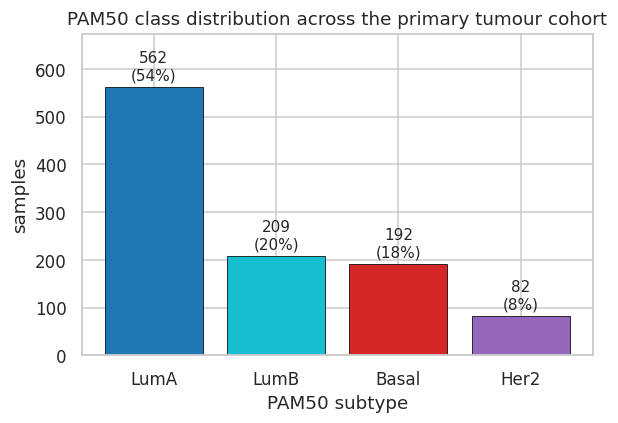

In [4]:
fig, ax = plt.subplots(figsize=(6.0, 3.8))
bars = ax.bar(
    CLASS_ORDER,
    counts.values,
    color=[CLASS_PALETTE[c] for c in CLASS_ORDER],
    edgecolor="black",
    linewidth=0.5,
)
for bar, n in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + counts.max() * 0.015,
        f"{n}\n({n / counts.sum():.0%})",
        ha="center",
        va="bottom",
        fontsize=10,
    )
ax.set_ylabel("samples")
ax.set_xlabel("PAM50 subtype")
ax.set_title("PAM50 class distribution across the primary tumour cohort")
ax.set_ylim(0, counts.max() * 1.20)
plt.show()

The cohort is imbalanced: LumA covers ~54% and Her2 only ~8%, a roughly 7:1 ratio between the most and least common class. Without correction a classifier could ignore the minority classes and still report high accuracy, so the rare classes are sampled more often during training.

## 4&nbsp;&nbsp;Expression value distribution

To decide whether the matrix needs further normalisation, we plot the distribution of all expression values. The histogram uses a random subsample of ~2 M cells of the matrix and a log y-axis so the long tails are visible.

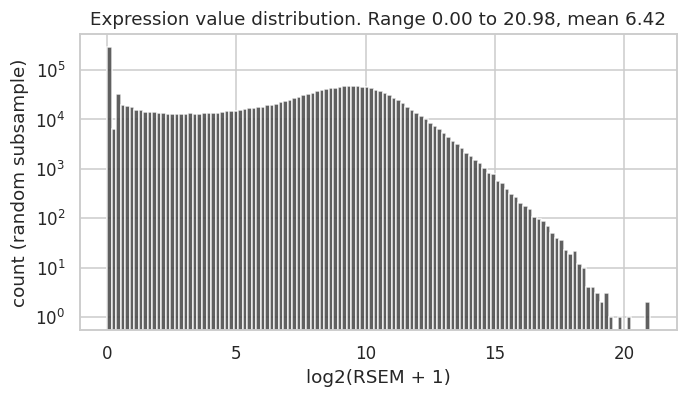

In [5]:
vals = X.values.ravel()
rng = np.random.default_rng(RNG)
sample_vals = rng.choice(vals, size=min(2_000_000, vals.size), replace=False)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(sample_vals, bins=120, color="#444444", alpha=0.85)
ax.set_yscale("log")
ax.set_xlabel("log2(RSEM + 1)")
ax.set_ylabel("count (random subsample)")
ax.set_title(
    f"Expression value distribution. Range {vals.min():.2f} to {vals.max():.2f}, mean {vals.mean():.2f}"
)
plt.show()

**Takeaway.** Values sit in roughly 0–21, with most expressed genes between log2 ≈ 1 and log2 ≈ 13. The data is already log-scaled by Xena, so the pipeline applies no further log or quantile transform; the only preprocessing step is a per-fold z-score using the training fold's mean and standard deviation. Computing the z-score per fold (rather than once on the whole matrix) keeps test-fold statistics out of the standardiser.

## 5&nbsp;&nbsp;Per gene variance

The selected MLP does not use all 20 530 genes. It keeps the top 10 000 by variance computed on the training fold, since a gene whose expression barely changes between samples cannot help separate subtypes. The histogram below shows where that cutoff lands in the variance distribution.

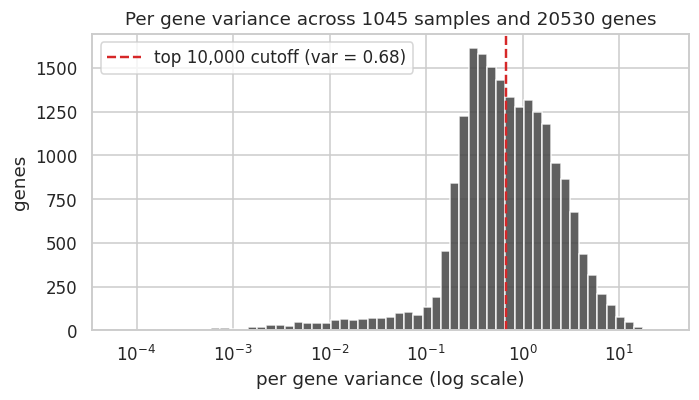

In [6]:
gene_var = X.var(axis=0)
v_min_pos = gene_var[gene_var > 0].min() if (gene_var > 0).any() else 1e-4
v_max = gene_var.max()
cutoff = gene_var.nlargest(TOP_K_GENES).min()

bins = np.logspace(np.log10(v_min_pos), np.log10(v_max), 60)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(gene_var.values, bins=bins, color="#444444", alpha=0.85)
ax.axvline(
    cutoff,
    color="#d62728",
    linestyle="--",
    linewidth=1.6,
    label=f"top {TOP_K_GENES:,} cutoff (var = {cutoff:.2f})",
)
ax.set_xscale("log")
ax.set_xlabel("per gene variance (log scale)")
ax.set_ylabel("genes")
ax.set_title(f"Per gene variance across {X.shape[0]} samples and {X.shape[1]} genes")
ax.legend(loc="upper left")
plt.show()

**Takeaway.** There is a long left tail of near-constant genes whose values barely move across the 1045 samples. These genes carry no usable signal for separating subtypes, only sequencing and normalisation noise. The cutoff at variance 0.68 sits to the right of that tail and keeps the half of the matrix that actually varies between samples.

## 6&nbsp;&nbsp;Class structure (PCA)

To check whether the four subtypes are at all separable in expression space, we project the standardised top-10 000-variance matrix to two dimensions with PCA. PCA is linear and deterministic, and the percentage of variance captured by each axis is directly meaningful. Each point is one tumour, coloured by its PAM50 label.

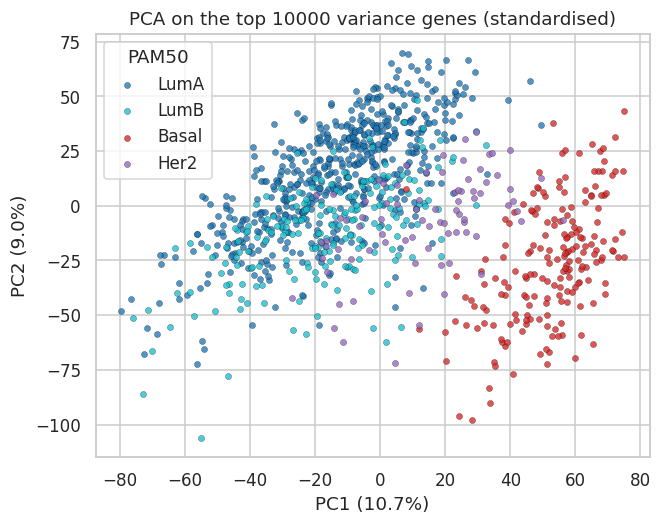

In [7]:
top_genes = gene_var.nlargest(TOP_K_GENES).index
X_top = X[top_genes].to_numpy()
X_std = StandardScaler().fit_transform(X_top)

pca = PCA(n_components=2, random_state=RNG)
Z = pca.fit_transform(X_std)
ev = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(6.5, 5.0))
for c in CLASS_ORDER:
    mask = (y["BRCA_Subtype_PAM50"] == c).to_numpy()
    ax.scatter(
        Z[mask, 0], Z[mask, 1],
        s=16, alpha=0.78, color=CLASS_PALETTE[c],
        edgecolor="black", linewidths=0.2, label=c,
    )
ax.set_xlabel(f"PC1 ({ev[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({ev[1] * 100:.1f}%)")
ax.set_title("PCA on the top 10000 variance genes (standardised)")
ax.legend(title="PAM50", frameon=True, loc="best")
plt.show()

**Takeaway.** Basal samples (red) collect on the right of PC1 and form a clean group even under a purely linear projection: the dominant axis of variation in BRCA expression is essentially Basal vs. the rest. The two Luminal classes overlap on the left, with Her2 mixing in along their boundary. Both observations match the held-out confusion matrix in the report (Figure 2), where Basal recall is ~0.98 and the largest off-diagonal entries are LumA ↔ LumB confusions.

## 7&nbsp;&nbsp;Class structure (UMAP)

PCA only captures linear structure and underestimates separability when the boundary between classes is curved. UMAP is a non-linear neighbour embedding that tries to preserve which points are close to which other points in the original space. We run it on the same standardised top-10 000-variance matrix to get a stricter view of the structure the model can exploit.

/opt/venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


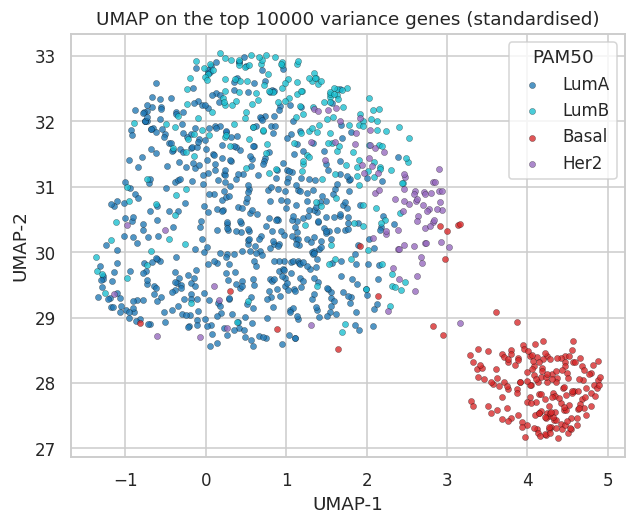

In [8]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    random_state=RNG,
)
U = reducer.fit_transform(X_std)

fig, ax = plt.subplots(figsize=(6.5, 5.0))
for c in CLASS_ORDER:
    mask = (y["BRCA_Subtype_PAM50"] == c).to_numpy()
    ax.scatter(
        U[mask, 0], U[mask, 1],
        s=16, alpha=0.78, color=CLASS_PALETTE[c],
        edgecolor="black", linewidths=0.2, label=c,
    )
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_title("UMAP on the top 10000 variance genes (standardised)")
ax.legend(title="PAM50", frameon=True, loc="best")
plt.show()

**Takeaway.** UMAP confirms the PCA picture. Basal samples form a tight separate island, which is why Basal is the easiest class for the model to recall. The other three subtypes share one large blob, with Her2 typically on the rim closer to the Basal island and LumA / LumB intermixed in the centre. This overlap does not contradict the 0.982 macro test AUC reported by the MLP, because AUC measures how well the model ranks samples within each class against the rest, not whether the classes form disjoint clusters in 2D.

## 8&nbsp;&nbsp;Biological sanity check

The previous plots show that the labels and the matrix are statistically separable, but they do not tell us whether the labels actually line up with known biology, or whether the join between the labels file and the expression matrix scrambled something. The standard quick check is to plot a few genes whose role in PAM50 is well known and confirm the per-class distributions go in the expected direction.

- **ESR1** codes for the estrogen receptor. The Luminal subtypes are estrogen-receptor positive by definition, so ESR1 should be markedly higher in LumA and LumB than in Basal or Her2.
- **ERBB2** is the HER2 gene. Its amplification defines the HER2-enriched subtype, so ERBB2 should peak in Her2.
- **MKI67** is a proliferation marker (only present in dividing cells). It is the standard feature separating LumA from LumB, so MKI67 should be lower in LumA and higher in LumB.

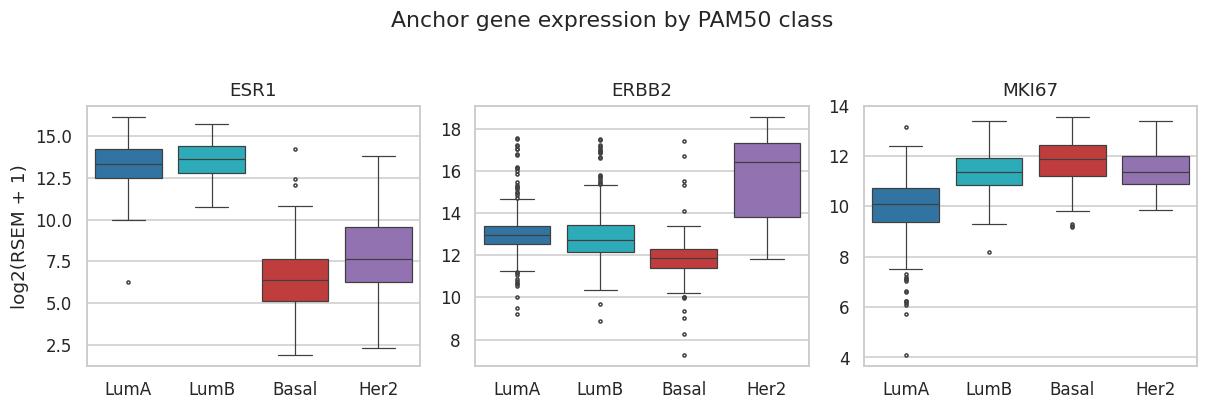

In [9]:
genes = ["ESR1", "ERBB2", "MKI67"]
df_long = X[genes].copy()
df_long["PAM50"] = y["BRCA_Subtype_PAM50"].to_numpy()
df_long = df_long.melt(
    id_vars="PAM50", var_name="gene", value_name="expression"
)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharey=False)
for ax, g in zip(axes, genes):
    sub = df_long[df_long["gene"] == g]
    sns.boxplot(
        data=sub,
        x="PAM50",
        y="expression",
        order=CLASS_ORDER,
        palette=CLASS_PALETTE,
        ax=ax,
        fliersize=2,
        linewidth=0.8,
        hue="PAM50",
        legend=False,
    )
    ax.set_title(g)
    ax.set_xlabel("")
    ax.set_ylabel("log2(RSEM + 1)" if ax is axes[0] else "")
fig.suptitle("Anchor gene expression by PAM50 class", y=1.03)
plt.tight_layout()
plt.show()

**Takeaway.** All three patterns hold. ESR1 is several units of log2 expression higher in LumA and LumB than in Basal and Her2. ERBB2 has a clearly elevated median in Her2 with an upward tail consistent with the gene amplification that defines the subtype. MKI67 is lower in LumA than in the other three classes and slightly higher in LumB, matching the expected proliferation gradient. The join between the labels file and the expression matrix is therefore correct, and no silent labelling or merge bug is present.

## 9&nbsp;&nbsp;Summary

- **Class imbalance is severe** (LumA ~54%, Her2 ~8%), so the MLP enables both `weighted_loss=True` and `weighted_sampling=True`.
- **Values are already log-scaled** by Xena and the matrix has no missing entries, so the only preprocessing step is a per-fold z-score on training-fold statistics.
- **A long tail of near-constant genes** appears in the variance histogram; the top-10 000-variance filter discards exactly that tail.
- **PCA and UMAP both isolate Basal** as a clean cluster while LumA, LumB, and Her2 overlap, which matches the 0.982 macro test AUC and the LumA ↔ LumB confusions in Figure 2.
- **The anchor genes ESR1, ERBB2, and MKI67** all separate the classes the way PAM50 biology predicts, confirming the labels and feature matrix are joined correctly.